# AEMET monthly climatology — Comunidad Valenciana

The second demo of the `xrtoolz.data.AemetSource` adapter scopes to one autonomous community — **Comunidad Valenciana** — and pulls 25 years of monthly climatological observations for every station in the region. The point of this notebook is to:

1. **Exercise the community-level `StationCollection.filter` API** at realistic scale (≈44 stations instead of three).
2. **Stress-test the archive** — this is ~10 chunks × 44 stations = hundreds of AEMET requests, sanity-checking parallel fetches, rate-limit back-off, and the GeoParquet merge.
3. **Show how to analyse an archive of stations.** Once the data is on disk as GeoParquet, all the analysis that follows uses plain `geopandas` / `pandas` / `matplotlib`: station map with long-term mean temperature, annual climatology, interannual warming signal, and a coastal-to-inland precipitation gradient.

Comunidad Valenciana is an instructive choice: it has a sharp coastal-to-inland climate gradient (Mediterranean at the coast, semi-arid / continental in the interior), strong autumn precipitation from DANA storms, and a clear summer warming signal over the satellite era.

## 1. Set up the adapter and the archive

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xrtoolz.data import AemetArchive, AemetSource


ROOT = Path(
    "/home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/aemet/valencia"
)
ROOT.mkdir(parents=True, exist_ok=True)

source = AemetSource(timeout_s=30.0, max_retries=4)
archive = AemetArchive(root=ROOT, source=source)

## 2. Filter the inventory to Comunidad Valenciana

`StationCollection.filter` takes any admin-hierarchy keyword (`city`, `province`, `community`). Matching is case-insensitive; `"comunidad valenciana"` and `"Comunidad Valenciana"` both work. The community is populated from our built-in province→community mapping (AEMET's inventory doesn't expose community directly).

In [2]:
inventory = archive.sync_stations()
valencia = inventory.filter(community="Comunidad Valenciana")
print(f"Total AEMET stations: {len(inventory)}")
print(f"Valencia stations:    {len(valencia)}")
print()
print("Provinces in the region:")
for p in valencia.provinces():
    n = len(valencia.filter(province=p))
    print(f"  {n:>3d}  {p}")

Total AEMET stations: 947
Valencia stations:    44

Provinces in the region:
   12  Alicante
   11  Castellón
   21  Valencia


The region spans three provinces — Alicante, Castellón, and Valencia — each with roughly a dozen AEMET stations. We'll see the province breakdown again on the map below.

## 3. Sync 25 years of monthly climatology

`since="2000-01-01"` keeps the scrape tractable (~900 AEMET calls) while still covering a meaningful climatological window. AEMET's monthly endpoint caps each request at 36 months; the adapter chunks wider spans internally and fetches chunks in parallel.

`sync()` is idempotent — re-running with the same window overwrites the overlapping rows. If the next run extends `until`, new months are appended.

In [3]:
ds = archive.sync(
    "aemet_monthly",
    stations=valencia,
    since="2000-01-01",
    until="2024-12-31",
)
print(f"Fresh slice: {ds.sizes}   ({len(ds.data_vars)} value columns)")

/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 7261X: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8005X: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 7261X: AEMET data-hop failed: 500 <!DOCTYPE html><html><head><title>Apache Tomcat/8.0.32 - Error report</title><style type="text/css">H1 {font-family:Tahoma,Arial,sans-serif;color:white;background-color:#525D76;font-size:22px;} H2 {fo
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8005X: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8018X: AEMET data-hop failed: 500 <!DOCTYPE html><html><head><title>Apache Tomcat/8.0.32 - Error report</title><style type="text/css">H1 {font-family:Tahoma,Arial,sans-serif;color:white;background-color:#525D76;font-size:22px;} H2 {fo
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8019: AEMET data-hop failed: 500 <!DOCTYPE html><html><head><title>Apache Tomcat/8.0.32 - Error report</title><style type="text/css">H1 {font-family:Tahoma,Arial,sans-serif;color:white;background-color:#525D76;font-size:22px;} H2 {fo
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8019: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)


...

/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8500A: AEMET data-hop failed: 500 <!DOCTYPE html><html><head><title>Apache Tomcat/8.0.32 - Error report</title><style type="text/css">H1 {font-family:Tahoma,Arial,sans-serif;color:white;background-color:#525D76;font-size:22px;} H2 {fo
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8501: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8523X: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)
/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 8523X: AEMET data-hop failed: 500 <!DOCTYPE html><html><head><title>Apache Tomcat/8.0.32 - Error report</title><style type="text/css">H1 {font-family:Tahoma,Arial,sans-serif;color:white;background-color:#525D76;font-size:22px;} H2 {fo
  return source.get_monthly(sids, time=tr)


/home/azureuser/localfiles/xrtoolz/src/xrtoolz/data/_src/aemet/archive.py:450: UserWarning: AEMET chunk failed for station 9562X: AEMET rate limit, retries exhausted
  return source.get_monthly(sids, time=tr)


Fresh slice: Frozen({'station': 44, 'time': 300})   (10 value columns)


## 4. Open the archive as a GeoDataFrame

The on-disk format is **long-format GeoParquet**: one row per `(station_id, time)`, with a `geometry` column carrying each station's EPSG:4326 point. Reading is a one-liner for anyone with `geopandas`; no xarray or custom schema required.

In [4]:
obs = archive.load("aemet_monthly")
stations_gdf = archive.load_stations_geodataframe()
stations_picked = stations_gdf[stations_gdf["id"].isin(obs["station_id"].unique())]
print(f"rows:        {len(obs):,}")
print(f"stations:    {obs['station_id'].nunique()}")
print(f"time range:  {obs['time'].min()}  →  {obs['time'].max()}")
print(f"CRS:         {obs.crs.to_epsg()} (EPSG)")
obs.head(3)

rows:        13,200
stations:    44
time range:  2000-01-01 00:00:00  →  2024-12-01 00:00:00
CRS:         4326 (EPSG)


,station_id,time,lon,lat,air_temperature_daily_mean,air_temperature_daily_min,air_temperature_daily_max,precipitation_amount,wind_speed_daily_mean,wind_speed_of_gust_daily,surface_pressure_hpa,surface_pressure_max_hpa,surface_pressure_min_hpa,sunshine_duration_daily,geometry
0,7244X,2000-01-01,-0.981389,38.067778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-0.98139 38.06778)
1,7244X,2000-02-01,-0.981389,38.067778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-0.98139 38.06778)
2,7244X,2000-03-01,-0.981389,38.067778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (-0.98139 38.06778)


## 5. Coverage diagnostics

Not every station is equally useful. Some have long records, some are recent, some are gappy. `archive.coverage(preset)` surfaces first/last timestamps and the gap fraction for a representative variable (default: `air_temperature_daily_mean`).

In [5]:
coverage = pd.DataFrame(
    {
        "station_id": [c.station_id for c in archive.coverage("aemet_monthly")],
        "first": [c.first for c in archive.coverage("aemet_monthly")],
        "last": [c.last for c in archive.coverage("aemet_monthly")],
        "n_timesteps": [c.n_timesteps for c in archive.coverage("aemet_monthly")],
        "gap_fraction": [c.gap_fraction for c in archive.coverage("aemet_monthly")],
    }
)
coverage = coverage.sort_values("n_timesteps", ascending=False).reset_index(drop=True)
print(
    f"stations with full 25-year record (0% gaps): {(coverage['gap_fraction'] == 0).sum()}"
)
print(
    f"stations with ≥90% coverage:                 {(coverage['gap_fraction'] <= 0.1).sum()}"
)
print(
    f"stations with <50% coverage:                 {(coverage['gap_fraction'] >= 0.5).sum()}"
)
coverage.head(10)

stations with full 25-year record (0% gaps): 0
stations with ≥90% coverage:                 0
stations with <50% coverage:                 18


,station_id,first,last,n_timesteps,gap_fraction
0,8309X,2000-01-01,2024-12-01,256,0.146667
1,8325X,2000-01-01,2024-12-01,241,0.196667
2,8050X,2000-02-01,2023-12-01,233,0.223333
3,8025,2006-01-01,2024-12-01,228,0.240000
4,8416Y,2005-04-01,2024-12-01,226,0.246667
5,8503Y,2005-03-01,2024-11-01,223,0.256667
6,8008Y,2005-05-01,2024-12-01,223,0.256667
7,9563X,2000-02-01,2024-12-01,214,0.286667
8,7261X,2000-01-01,2023-12-01,209,0.303333
9,7247X,2004-02-01,2024-12-01,208,0.306667


## 6. Station map coloured by long-term mean temperature

We join the station metadata with the per-station long-term `air_temperature_daily_mean` so the map encodes *where it's hot*. The coastal Mediterranean stations should sit at the warm end; interior Castellón and Alicante highland stations at the cool end.

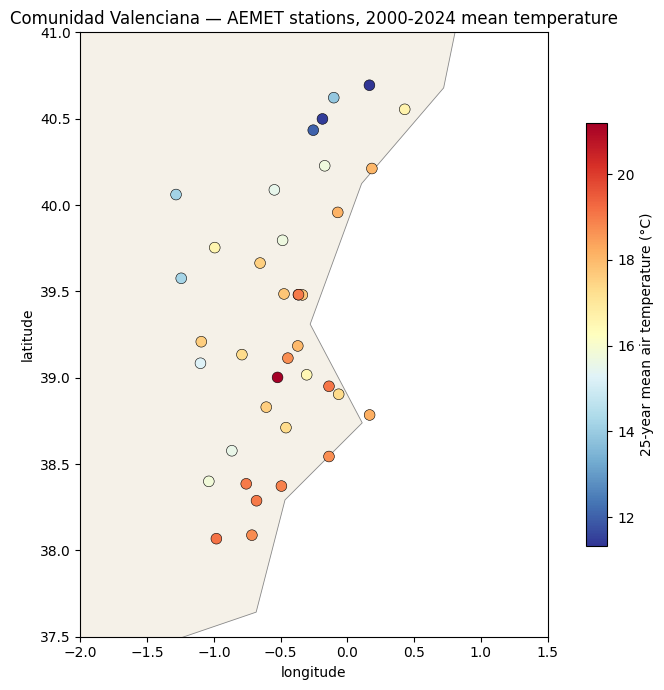

In [6]:
lt_mean = (
    obs.groupby("station_id")["air_temperature_daily_mean"].mean().rename("tmean_25yr")
)
map_gdf = stations_picked.merge(lt_mean, left_on="id", right_index=True, how="inner")

try:
    world = gpd.read_file(
        "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    )
except Exception:
    world = None

fig, ax = plt.subplots(figsize=(8, 7))
if world is not None:
    spain = world.cx[-10:5, 35:45]
    spain.plot(ax=ax, color="#f5f1e8", edgecolor="#888", linewidth=0.6)
plot = map_gdf.plot(
    ax=ax,
    column="tmean_25yr",
    cmap="RdYlBu_r",
    legend=True,
    legend_kwds={"label": "25-year mean air temperature (°C)", "shrink": 0.7},
    edgecolor="black",
    linewidth=0.4,
    markersize=60,
)
ax.set_xlim(-2.0, 1.5)
ax.set_ylim(37.5, 41.0)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Comunidad Valenciana — AEMET stations, 2000-2024 mean temperature")
plt.tight_layout()
plt.show()

Warm colours cluster along the coast (Alicante, Castellón, Valencia city); cooler colours sit inland at elevation. Gaps on the map correspond to stations filtered out because they don't have a temperature record (which is rare at monthly cadence).

## 7. Annual cycle — monthly climatology across the region

Averaging each calendar month across years and across stations gives the classic "annual cycle" plot. Valencia shows the Mediterranean signature: a gentle seasonal temperature amplitude, a dry summer, and a bimodal precipitation distribution with peaks in spring and autumn.

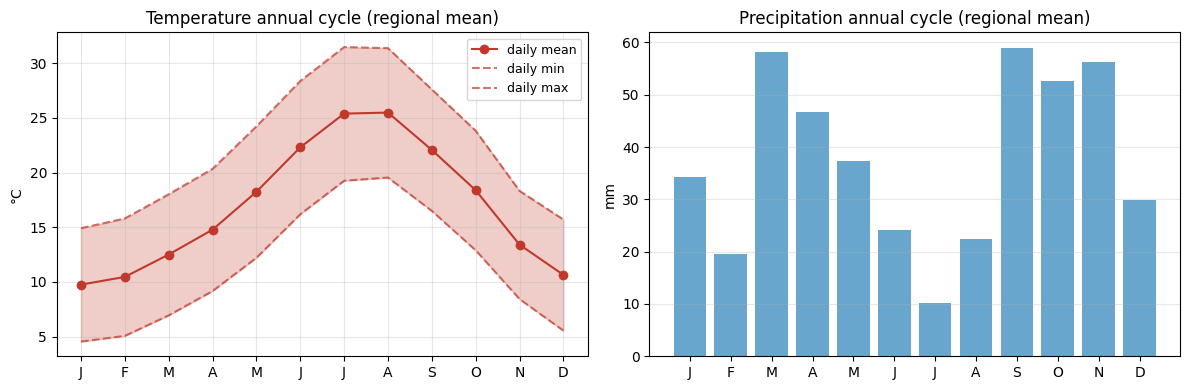

In [7]:
obs_clim = obs.copy()
obs_clim["month"] = pd.to_datetime(obs_clim["time"]).dt.month
clim = (
    obs_clim.groupby("month")
    .agg(
        tmean=("air_temperature_daily_mean", "mean"),
        tmin=("air_temperature_daily_min", "mean"),
        tmax=("air_temperature_daily_max", "mean"),
        precip=("precipitation_amount", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].fill_between(
    clim["month"], clim["tmin"], clim["tmax"], alpha=0.25, color="#c0392b"
)
axes[0].plot(
    clim["month"], clim["tmean"], marker="o", color="#c0392b", label="daily mean"
)
axes[0].plot(
    clim["month"],
    clim["tmin"],
    color="#c0392b",
    linestyle="--",
    alpha=0.7,
    label="daily min",
)
axes[0].plot(
    clim["month"],
    clim["tmax"],
    color="#c0392b",
    linestyle="--",
    alpha=0.7,
    label="daily max",
)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
axes[0].set_ylabel("°C")
axes[0].set_title("Temperature annual cycle (regional mean)")
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].bar(clim["month"], clim["precip"], color="#2980b9", alpha=0.7)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
axes[1].set_ylabel("mm")
axes[1].set_title("Precipitation annual cycle (regional mean)")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 8. Interannual variability and a warming signal

Collapse to annual means (regional mean temperature per year) and look at the trend. A simple linear fit quantifies the warming rate over the scrape window.

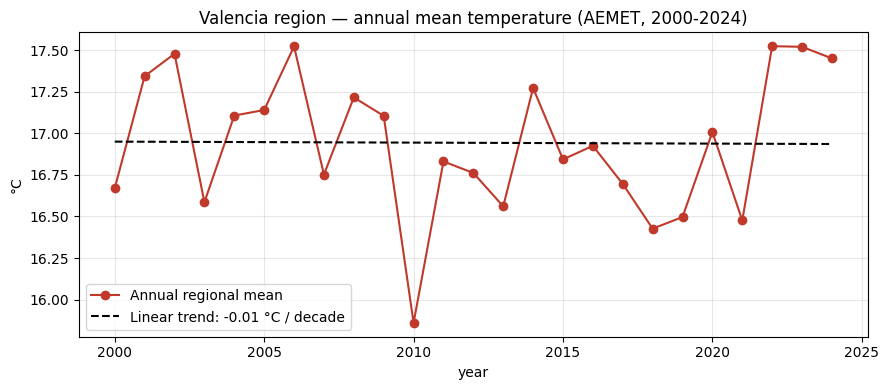


Warming rate over 2000–2024: -0.01 °C per decade


In [8]:
obs_ann = obs.copy()
obs_ann["year"] = pd.to_datetime(obs_ann["time"]).dt.year
annual = obs_ann.groupby("year")["air_temperature_daily_mean"].mean().reset_index()
# Drop years with partial data (first/last of the window may be incomplete).
full_years = annual["year"].between(2000, 2024)
annual = annual[full_years].reset_index(drop=True)

slope, intercept = np.polyfit(annual["year"], annual["air_temperature_daily_mean"], 1)
fit = slope * annual["year"] + intercept

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    annual["year"],
    annual["air_temperature_daily_mean"],
    marker="o",
    color="#c0392b",
    label="Annual regional mean",
)
ax.plot(
    annual["year"],
    fit,
    linestyle="--",
    color="black",
    label=f"Linear trend: {slope * 10:+.2f} °C / decade",
)
ax.set_xlabel("year")
ax.set_ylabel("°C")
ax.set_title("Valencia region — annual mean temperature (AEMET, 2000-2024)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"\nWarming rate over {annual['year'].min()}–{annual['year'].max()}: "
    f"{slope * 10:+.2f} °C per decade"
)

## 9. Coastal–interior precipitation gradient

Valencia's precipitation is strongly structured by distance from the coast and by altitude. With the GeoParquet archive it's one line of `geopandas` to plot annual mean precipitation as a proportional symbol map.

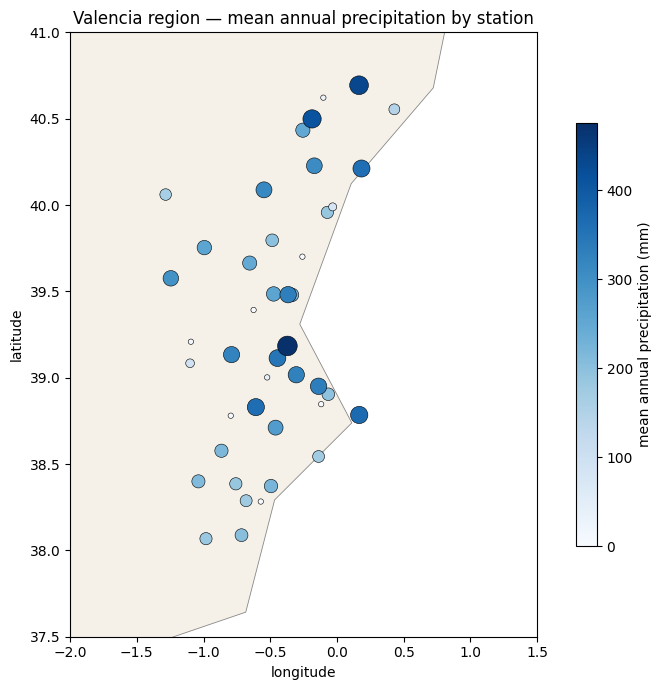

In [9]:
ann_precip = (
    obs_ann.groupby(["station_id", "year"])["precipitation_amount"]
    .sum()
    .groupby("station_id")
    .mean()
    .rename("annual_precip_mm")
)
precip_gdf = stations_picked.merge(
    ann_precip, left_on="id", right_index=True, how="inner"
)

fig, ax = plt.subplots(figsize=(8, 7))
if world is not None:
    spain = world.cx[-10:5, 35:45]
    spain.plot(ax=ax, color="#f5f1e8", edgecolor="#888", linewidth=0.6)
precip_gdf.plot(
    ax=ax,
    column="annual_precip_mm",
    cmap="Blues",
    legend=True,
    legend_kwds={"label": "mean annual precipitation (mm)", "shrink": 0.7},
    edgecolor="black",
    linewidth=0.4,
    markersize=(
        precip_gdf["annual_precip_mm"] / precip_gdf["annual_precip_mm"].max() * 200
    ).clip(lower=15),
)
ax.set_xlim(-2.0, 1.5)
ax.set_ylim(37.5, 41.0)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title("Valencia region — mean annual precipitation by station")
plt.tight_layout()
plt.show()

## 10. Summary

The scrape wrote one GeoParquet file per preset, plus the inventory:

```
valencia/
  aemet_monthly.parquet    # long-format observations with geometry
  stations.parquet         # station inventory
```

Both are directly consumable by anything that reads GeoParquet — geopandas, DuckDB, Apache Arrow, Fiona, GDAL. The xarray cube view remains available via `archive.load_dataset("aemet_monthly")` when dense `(station, time)` operations are more convenient than long-format queries.

Re-running this notebook at a later date will only fetch the new months (since the archive resumes from the last stored time per station). The smoke test at `aemet_smoke.py` exercises the same APIs on a hand-picked three-station slice; the full-national scrape lives in a third notebook.